# Trabajo Práctico AA1 - Clasificación

In [197]:
# manipulación, visualización y modelado.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# separación de datos, modelos y métricas.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score, auc

# preprocesamiento.
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## Carga dataset

In [198]:
# Cargamos el dataset
df_original = pd.read_csv("/content/weatherAUS_2026C1.csv")
df_original.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [199]:
#copiamos el dataset para mantener el original
df = df_original.copy()

In [200]:
# revisamos las columnas
df.columns

Index(['Unnamed: 0', 'Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall',
       'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am',
       'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow', 'RainfallTomorrow'],
      dtype='object')

In [201]:
# cantidad de filas y columnas
df.shape

(145412, 25)

In [202]:
# revisamos tipos de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  object 
 2   Location          145412 non-null  object 
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  object 
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  object 
 11  WindDir3pm        141186 non-null  object 
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  float64
 16  Pressure9am       13

In [203]:
df.isnull().sum()

,0
Unnamed: 0,0
Date,0
Location,0
MinTemp,1484
MaxTemp,1253
Rainfall,3260
Evaporation,62754
Sunshine,69796
WindGustDir,10316
WindGustSpeed,10253


Se detectan valores faltantes en varias columnas, por lo que será necesario tratarlo según el caso.

In [204]:
df = df.drop(columns=["Unnamed: 0"])

La columna "Unnamed: 0" parece ser un índice guardado en el archivo CSV, por lo que no representa una variable climática útil para la predicción. Por este motivo se elimina del análisis.

In [205]:
df = df.drop(columns=["RainfallTomorrow"])

In [206]:
# verificamos que hayan sido eliminadas
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

La columna "RainfallTomorrow" no se utiliza como variable predictora porque contiene información asociada al día siguiente. Como el objetivo es predecir a las 23:59 hs si al día siguiente lloverá o no, esta información no estaría disponible al momento de realizar la predicción. Usarla produciría fuga de datos.

## EDA

In [207]:
# revisamos los valores de la variable objetivo
df["RainTomorrow"].value_counts(dropna=False)

,count
RainTomorrow,
No,110281
Yes,31872
NaN,3259


In [208]:
# Calculamos la proporción de cada clase
df["RainTomorrow"].value_counts(normalize=True, dropna=False)

,proportion
RainTomorrow,
No,0.758404
Yes,0.219184
NaN,0.022412


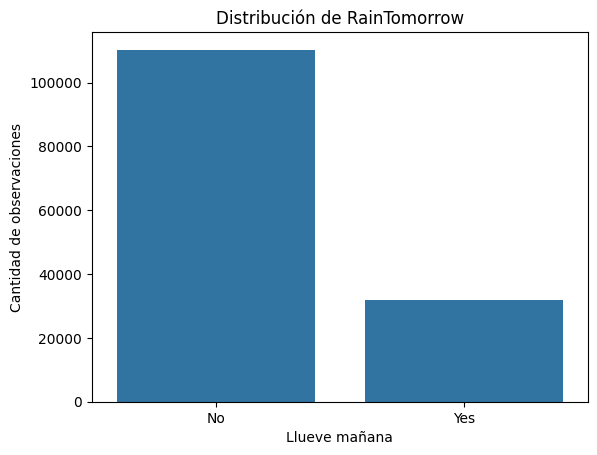

In [209]:
# Graficamos la distribución de la variable objetivo
sns.countplot(data=df, x="RainTomorrow")
plt.title("Distribución de RainTomorrow")
plt.xlabel("Llueve mañana")
plt.ylabel("Cantidad de observaciones")
plt.show()

La variable objetivo del problema es "RainTomorrow", que indica si al día siguiente llovió o no. En distribución observamos que la clase "No" aparece con mucha mayor frecuencia que la clase "Yes". Por ende el dataset está desbalanceado, por este motivo, además de accuracy, será necesario observar métricas como precision, recall y F1-score, especialmente para la clase "Yes". Sino el modelo puede no aprender a detectar bien los dias que si llueve


In [210]:
# eliminamos filas donde la variable objetivo no tiene valor
df = df.dropna(subset=["RainTomorrow"])

In [211]:
# verificamos
df["RainTomorrow"].value_counts(dropna=False)

,count
RainTomorrow,
No,110281
Yes,31872


Las filas con valores faltantes en "RainTomorrow" se eliminan porque esta columna es la variable objetivo. Si no se conoce si al día siguiente llovió o no, esa observación no puede utilizarse para entrenar ni evaluar un modelo supervisado.

In [212]:
# calculamos cantidad y porcentaje de valores faltantes por columna
faltantes = pd.DataFrame({
    "cantidad_faltantes": df.isna().sum(),
    "porcentaje_faltantes": df.isna().mean() * 100
})

faltantes = faltantes.sort_values(by="porcentaje_faltantes", ascending=False)

faltantes

,cantidad_faltantes,porcentaje_faltantes
Sunshine,67785,47.684537
Evaporation,60812,42.779259
Cloud3pm,57076,40.151105
Cloud9am,53641,37.734694
Pressure9am,14010,9.855578
Pressure3pm,13977,9.832364
WindDir9am,10009,7.041005
WindGustDir,9328,6.561944
WindGustSpeed,9268,6.519736
WindDir3pm,3776,2.656293


Observamos que algunas variables presentan un porcentaje alto de valores faltantes, por este motivo no se eliminan filas completas con valores faltantes, ya que eso implicaría perder una gran cantidad de observaciones. Se decide conservar inicialmente las variables y realizar la imputación más adelante después de separar los datos en entrenamiento y prueba.


In [213]:
# identificamos variables numéricas y categóricas
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns
columnas_categoricas = df.select_dtypes(include=["object"]).columns

print("Variables numéricas:")
print(columnas_numericas)

print("\nVariables categóricas:")
print(columnas_categoricas)

Variables numéricas:
Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='object')

Variables categóricas:
Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='object')


In [214]:
# obtenemos medidas descriptivas de las variables numéricas
df[columnas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
MinTemp,141516.0,12.188866,6.422856,-9.7,7.6,12.0,16.8,34.1
MaxTemp,141831.0,23.228596,7.134436,-5.1,17.9,22.6,28.2,49.1
Rainfall,140747.0,2.350461,8.466267,0.0,0.0,0.0,0.8,371.0
Evaporation,81341.0,5.470149,4.188649,0.0,2.6,4.8,7.4,145.0
Sunshine,74368.0,7.624919,3.781656,0.0,4.9,8.5,10.6,14.5
WindGustSpeed,132885.0,39.985807,13.630314,6.0,31.0,38.0,48.0,135.0
WindSpeed9am,140805.0,14.025219,8.914326,0.0,7.0,13.0,19.0,130.0
WindSpeed3pm,139524.0,18.636901,8.858849,0.0,12.0,18.0,24.0,86.0
Humidity9am,140379.0,68.824619,19.085026,0.0,56.9,69.9,83.1,100.0
Humidity3pm,138544.0,51.475886,20.846540,0.0,36.5,51.9,65.6,100.0


Calculamos las medidas para las variables numéricas para detectar diferencias de escala entre variables

In [215]:
# obtenemos un resumen de las variables categóricas.
df[columnas_categoricas].describe().T

,count,unique,top,freq
Date,142153,3435,2017-06-21,49
Location,142153,49,Canberra,3417
WindGustDir,132825,16,W,9775
WindDir9am,132144,16,N,11389
WindDir3pm,138377,16,SE,10662
RainToday,140747,2,No,109296
RainTomorrow,142153,2,No,110281


En este caso interesa observar cuántas categorías distintas tiene cada variable y cuál es el valor más frecuente

### Histogramas

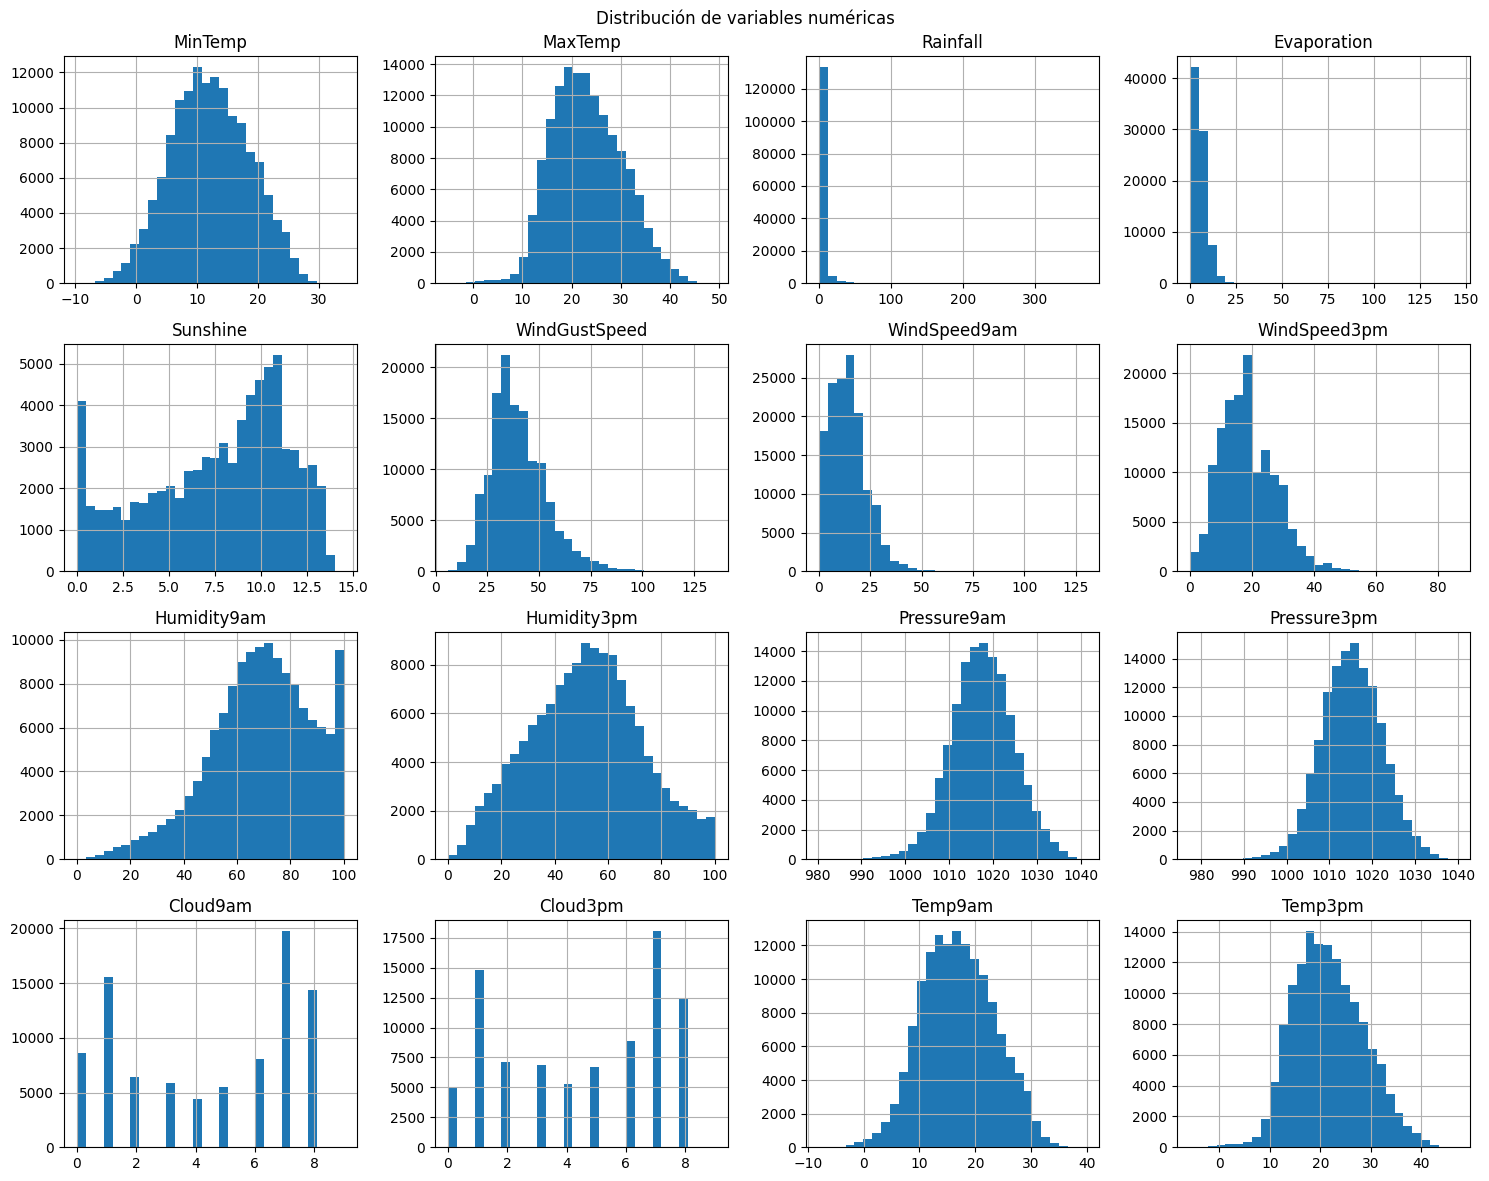

In [216]:
# graficamos histogramas para observar la distribución de las variables numéricas.
df[columnas_numericas].hist(figsize=(15, 12), bins=30)
plt.suptitle("Distribución de variables numéricas")
plt.tight_layout()
plt.show()

Graficamos histogramas de las variables numéricas para observar su distribución. Observamos que las variables no se encuentran en la misma escala, por ejemplo, temperatura, presión, humedad, velocidad del viento y lluvia tienen unidades y rangos distintos. Por este motivo, más adelante será necesario aplicar escalado

### Boxplots

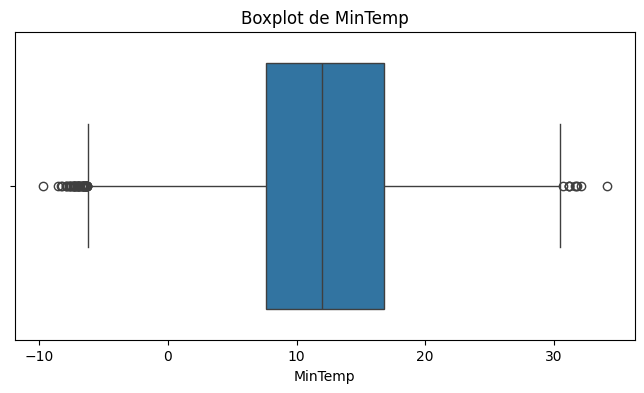

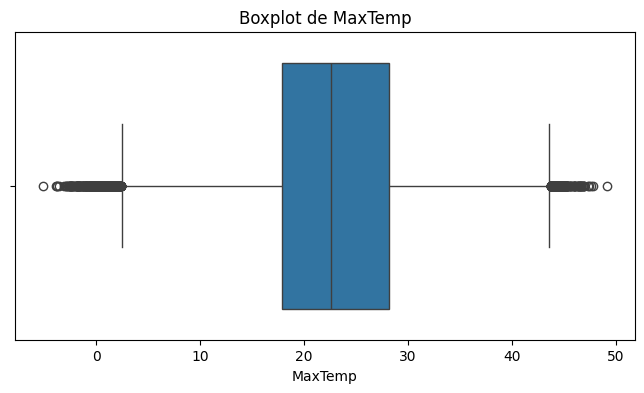

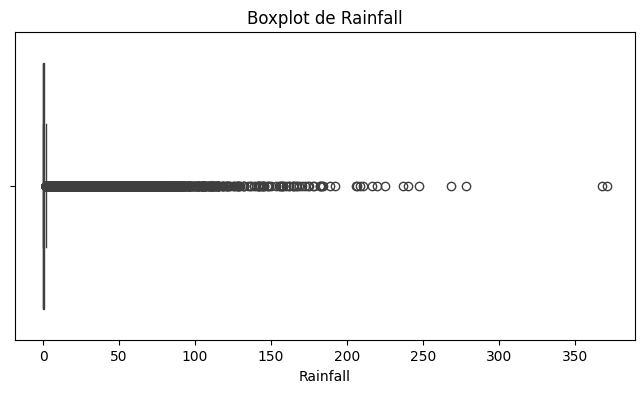

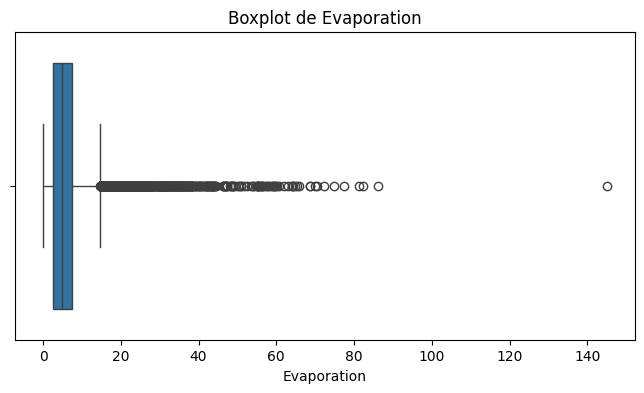

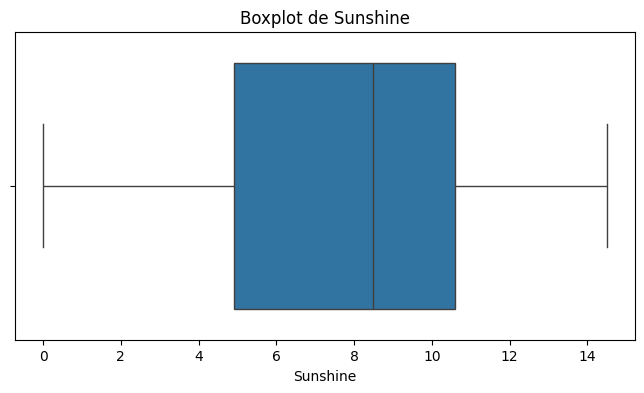

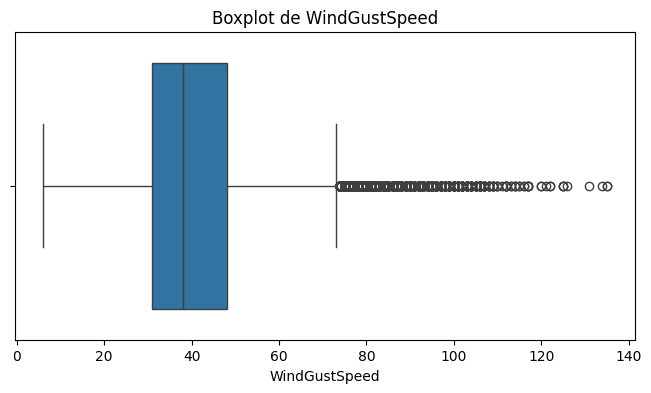

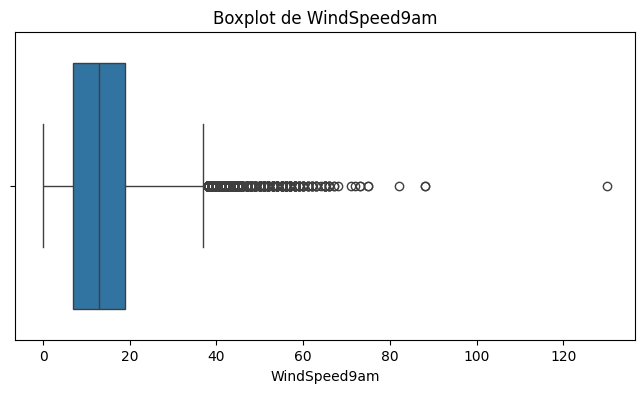

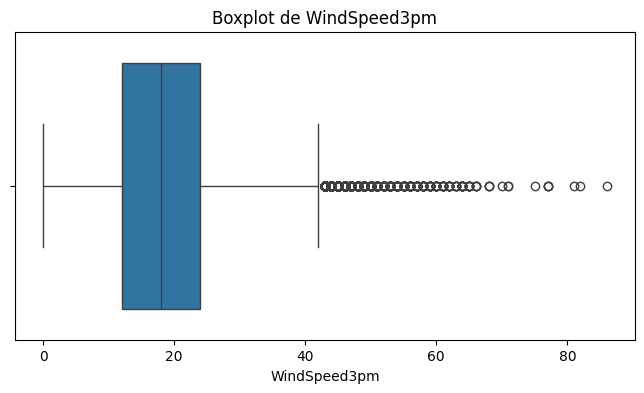

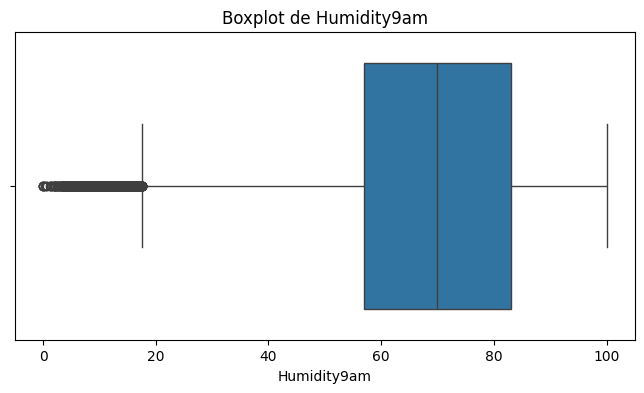

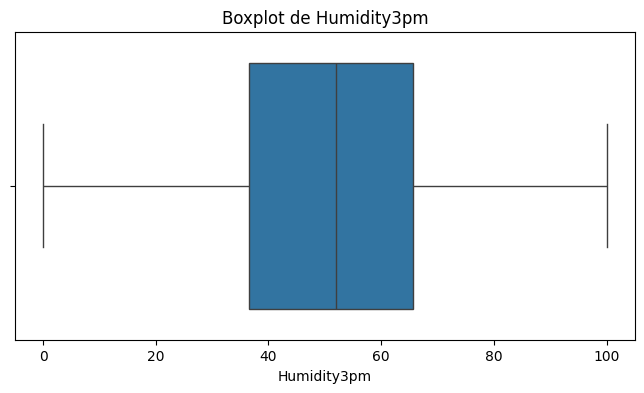

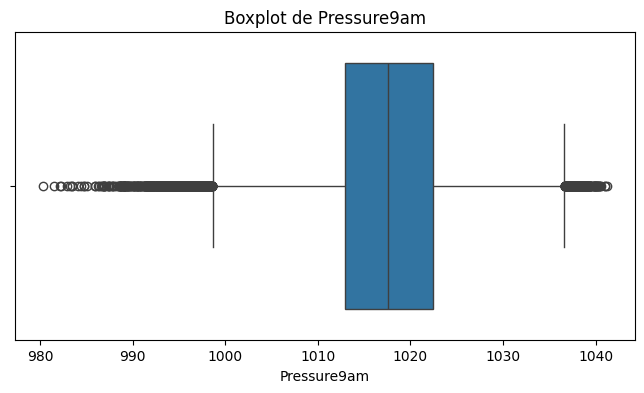

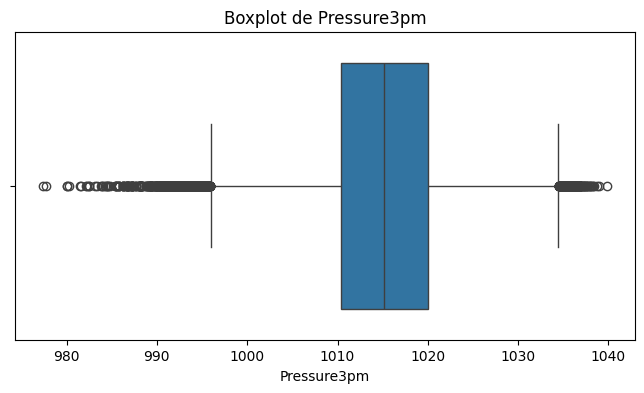

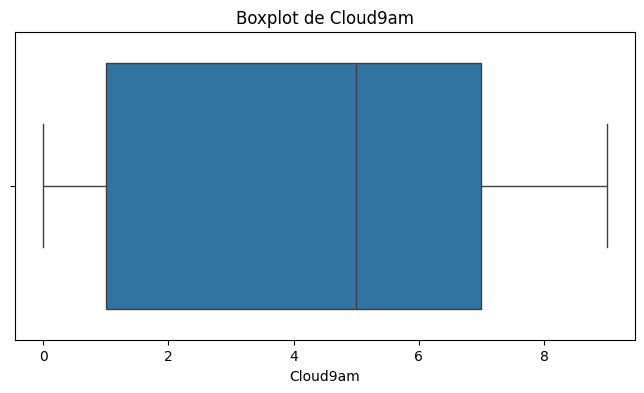

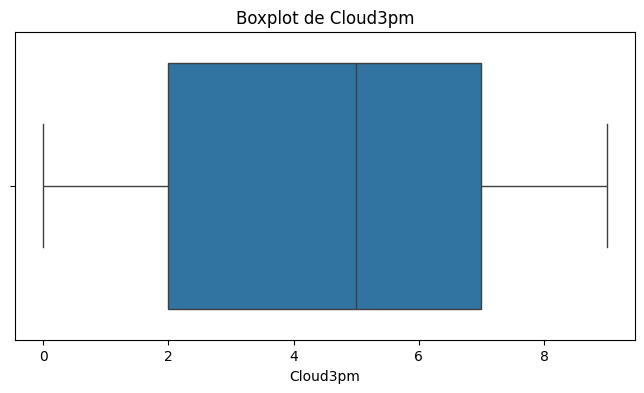

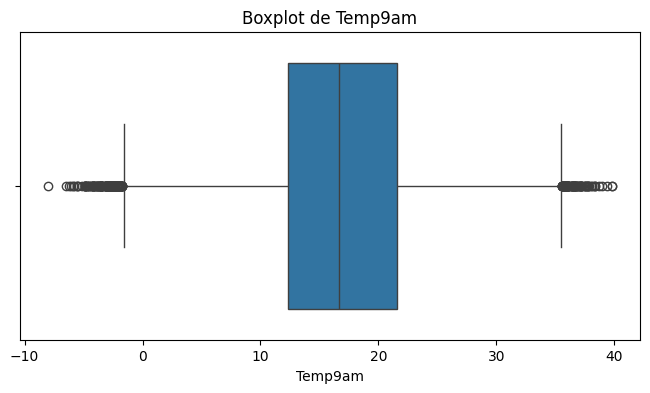

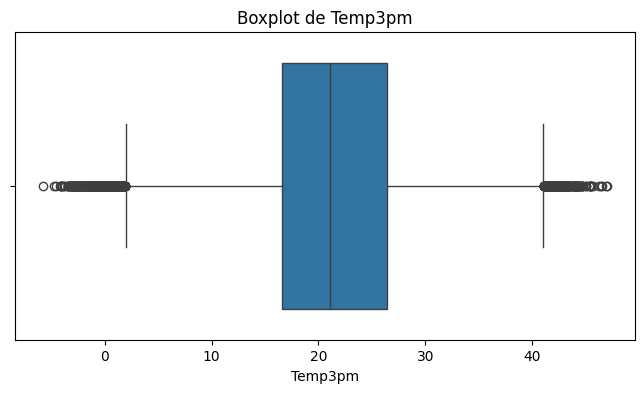

In [217]:
# Graficamos boxplots individuales para todas las variables numéricas.
for columna in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=columna)
    plt.title(f"Boxplot de {columna}")
    plt.xlabel(columna)
    plt.show()

In [218]:
# calculamos outliers por variable numérica usando el criterio del rango intercuartílico
resumen_outliers = []

for columna in columnas_numericas:
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    cantidad_outliers = ((df[columna] < limite_inferior) | (df[columna] > limite_superior)).sum()

    porcentaje_outliers = cantidad_outliers / df[columna].notna().sum() * 100

    resumen_outliers.append({
        "variable": columna,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "cantidad_outliers": cantidad_outliers,
        "porcentaje_outliers": porcentaje_outliers
    })

resumen_outliers = pd.DataFrame(resumen_outliers)
resumen_outliers.sort_values(by="porcentaje_outliers", ascending=False)

,variable,limite_inferior,limite_superior,cantidad_outliers,porcentaje_outliers
2,Rainfall,-1.20,2.00,25224,17.921519
3,Evaporation,-4.60,14.60,1954,2.402233
5,WindGustSpeed,5.50,73.50,2899,2.181586
6,WindSpeed9am,-11.00,37.00,1891,1.342992
7,WindSpeed3pm,-6.00,42.00,1663,1.191910
8,Humidity9am,17.60,122.40,1425,1.015109
10,Pressure9am,998.65,1036.65,1181,0.921627
11,Pressure3pm,996.00,1034.40,915,0.713862
15,Temp3pm,1.90,41.10,752,0.539346
1,MaxTemp,2.45,43.65,485,0.341956


In [219]:
# verificamos si existen valores negativos en variables que no deberían ser negativas
variables_no_negativas = ["Rainfall", "Evaporation", "Sunshine","WindGustSpeed", "WindSpeed9am", "WindSpeed3pm","Humidity9am", "Humidity3pm","Pressure9am", "Pressure3pm", "Cloud9am", "Cloud3pm"]

valores_negativos = {}

for columna in variables_no_negativas:
    cantidad_negativos = (df[columna] < 0).sum()
    valores_negativos[columna] = cantidad_negativos

pd.Series(valores_negativos).sort_values(ascending=False)

,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustSpeed,0
WindSpeed9am,0
WindSpeed3pm,0
Humidity9am,0
Humidity3pm,0
Pressure9am,0
Pressure3pm,0


In [220]:
# observamos los valores más frecuentes de Rainfall
df["Rainfall"].value_counts().head(20)

,count
Rainfall,
0.0,90244
0.2,8681
0.4,3749
0.6,2562
0.8,2028
1.0,1747
1.2,1515
1.4,1365
1.6,1187


Analizamos posibles valores extremos utilizando el criterio del rango intercuartílico (IQR). Este criterio marca como posibles outliers los valores menores a Q1 - 1.5 * IQR o mayores a Q3 + 1.5 * IQR. Observamos también que una gran parte de las observaciones tiene lluvia igual o cercana a 0 mm. Esto hace que el rango intercuartílico sea bajo y que valores de lluvia mayores a 2 mm sean marcados como outliers. Estos valores no necesariamente representan errores, sino que pueden ser días con mayor cantidad de lluvia.

### Matriz de correlación

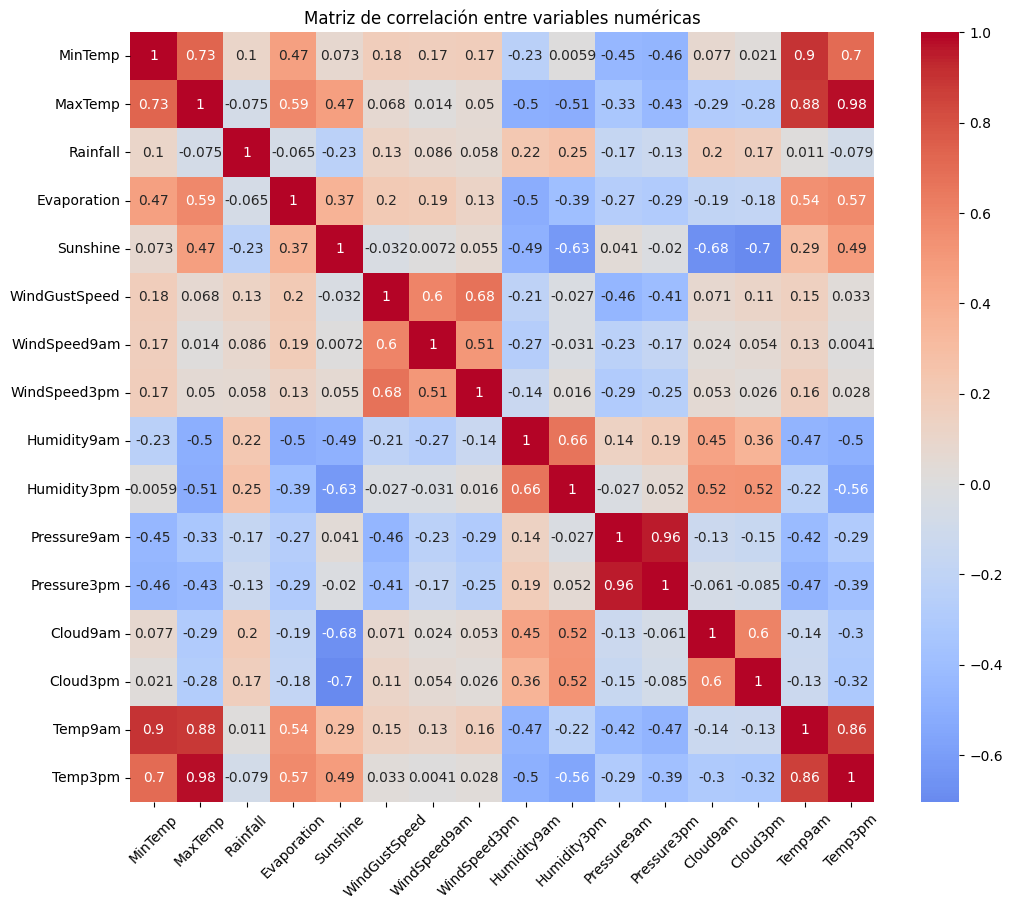

In [221]:
# calculamos la matriz de correlación entre variables numéricas
correlacion = df[columnas_numericas].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlacion, cmap="coolwarm", center=0, annot=True)
plt.title("Matriz de correlación entre variables numéricas")
plt.xticks(rotation=45)
plt.show()

Se identifican correlaciones positivas fuertes entre variables relacionadas con la temperatura, como "MaxTemp" y "Temp3pm", y entre variables de presión, como "Pressure9am" y "Pressure3pm", también se observan correlaciones negativas entre "Sunshine" y variables como "Cloud9am", "Cloud3pm" y "Humidity3pm", lo cual es coherente con el clima, a mayor nubosidad o humedad o menor cantidad de horas de sol.
Esta matriz se utiliza como análisis exploratorio. No se eliminan variables automáticamente por correlación en esta etapa

In [222]:
# creamos una copia para preparar los datos que se usarán en los modelos
df_modelo = df.copy()

In [223]:
# convertimos Date a formato fecha y extraemos el mes como variable numérica
df_modelo["Date"] = pd.to_datetime(df_modelo["Date"])
df_modelo["Month"] = df_modelo["Date"].dt.month

# eliminamos la columna Date original para evitar codificar fechas completas
df_modelo = df_modelo.drop(columns=["Date"])

La columna "Date" se convierte a formato fecha y se utiliza para extraer el mes de la observación, lo que perermite conservar información  sobre estaciones, ya que la probabilidad de lluvia puede variar según la época del año. Luego se elimina la fecha completa, porque codificar cada día como una categoría distinta generaría muchas columnas y no aportaría una representación simple para el modelo.

In [224]:
# separamos variables predictoras y variable objetivo.
X = df_modelo.drop(columns=["RainTomorrow"])
y = df_modelo["RainTomorrow"]

In [225]:
# codificamos la variable objetivo: No = 0, Yes = 1.
y = y.map({"No": 0, "Yes": 1})

La variable objetivo se codifica como variable binaria donde "No" se representa con 0 y "Yes" con 1 para que la clase positiva corresponmda a los dias en los que si llueve

In [226]:
# ahora identificamos variables numéricas y categóricas dentro de X
columnas_numericas = X.select_dtypes(include=["int64", "float64"]).columns
columnas_categoricas = X.select_dtypes(include=["object"]).columns

print("Variables numéricas:")
print(columnas_numericas)

print("\nVariables categóricas:")
print(columnas_categoricas)

Variables numéricas:
Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='object')

Variables categóricas:
Index(['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday'], dtype='object')


Se vuelven a identificar las columnas numéricas y categóricas únicamente dentro de "X" para no incluir la variable objetivo dentro de las predictoras

In [227]:
# dividimos los datos en entrenamiento y prueba manteniendo la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

Se divide el dataset en conjuntos de entrenamiento y prueba. Usamos un 20% de los datos para prueba y se mantiene la proporción de clases mediante "stratify=y", ya que la variable objetivo está desbalanceada

In [229]:
# definimos el preprocesamiento para variables numéricas
preprocesamiento_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# definimos el preprocesamiento para variables categóricas
preprocesamiento_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# combinamos ambos preprocesamientos
preprocesamiento = ColumnTransformer(transformers=[
    ("num", preprocesamiento_numerico, columnas_numericas),
    ("cat", preprocesamiento_categorico, columnas_categoricas)
])

Separamos el preprocesamiento según tipo de variable. Para las numéricas usamos imputación con mediana y escalado estándar. Para las categóricas usamos imputación con la categoría más frecuente y codificación one-hot. Todo esto se coloca dentro de un Pipeline y un ColumnTransformer para que se ajuste solo con el conjunto de entrenamiento y así evitar fuga de datos.